In [235]:
import pandas as pd

raw_total = pd.read_hdf('tesla_preprocessed.h5', key='tesla_price')

In [236]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = raw_total[['open-close', 'low-high', 'is_quarter_end', 'Open', 'Close', 'High', 'Low']]
target = raw_total[['target', 'next_open',  'next_close', 'next_high', 'next_low']].values

scaler = StandardScaler()
features = scaler.fit_transform(features)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [237]:
x_train.shape, y_train.shape

((1352, 7), (1352, 5))

In [238]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [239]:
print("XLA JIT enabled by default:", tf.config.optimizer.get_jit())
print("GPU devices:", tf.config.list_physical_devices('GPU'))

XLA JIT enabled by default: 
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [240]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("CUDA built:", tf.sysconfig.get_build_info()["cuda_version"])
print("cuDNN built:", tf.sysconfig.get_build_info()["cudnn_version"])

TensorFlow version: 2.14.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CUDA built: 11.8
cuDNN built: 8


In [241]:
# -----------------------------
# 2. Scale the data
# -----------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_X.fit_transform(x_train)
x_test = scaler_X.transform(x_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)


In [242]:
def custom_loss(y_pred, y_true):
    loss = ( y_pred[0] - y_true[0])*0.7
    loss += tf.reduce_mean(tf.square(y_pred[1:] - y_true[1:]))*0.3

    return tf.square(loss)*10

In [243]:
# -----------------------------
# 3. Build the model function
# -----------------------------
def build_model(input_dim, output_dim, units=64, layers=2, dropout_rate=0.1, learning_rate=0.001):
    model = Sequential()
    model.add(Dense(units, activation='relu', input_shape=(input_dim,)))
    
    for _ in range(layers - 1):
        model.add(Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    
    # Output layer for regression
    model.add(Dense(output_dim, activation='linear'))
    
    # Compile
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model


In [244]:
# -----------------------------
# 4. Hyperparameters
# -----------------------------
input_dim = x_train.shape[1]
output_dim = y_train.shape[1] if len(y_train.shape) > 1 else 1

units = 64          # neurons per layer
layers = 3          # hidden layers
dropout_rate = 0.1
learning_rate = 0.001
batch_size = 32
epochs = 200

In [245]:
# -----------------------------
# 5. Callbacks
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)


In [246]:
import subprocess
import os

print("=== TensorFlow GPU Setup Check ===")
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Devices: {tf.config.list_physical_devices('GPU')}")

# Check CUDA
try:
    nvcc_result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
    if nvcc_result.returncode == 0:
        print("✓ NVCC found")
        # Extract CUDA version from nvcc output
        for line in nvcc_result.stdout.split('\n'):
            if 'release' in line:
                print(f"✓ {line.strip()}")
    else:
        print("✗ NVCC not found")
except:
    print("✗ NVCC check failed")

# Check for libdevice
cuda_paths = ['/usr/local/cuda', '/usr/local/cuda-11.8', '/opt/cuda']
libdevice_found = False

for path in cuda_paths:
    libdevice_path = os.path.join(path, 'nvvm', 'libdevice', 'libdevice.10.bc')
    if os.path.exists(libdevice_path):
        print(f"✓ Found libdevice at: {libdevice_path}")
        os.environ['XLA_FLAGS'] = f'--xla_gpu_cuda_data_dir={path}'
        libdevice_found = True
        break

if not libdevice_found:
    print("✗ libdevice.10.bc not found in standard locations")
    print("→ Using CPU mode for now")
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Now run your model
model = build_model(input_dim, output_dim, units, layers, dropout_rate, learning_rate)
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=2
)

=== TensorFlow GPU Setup Check ===
TensorFlow Version: 2.14.0
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ NVCC found
✓ Cuda compilation tools, release 12.0, V12.0.140
✓ Found libdevice at: /usr/local/cuda/nvvm/libdevice/libdevice.10.bc
Epoch 1/200
43/43 - 1s - loss: 0.5807 - mae: 0.6529 - val_loss: 0.2232 - val_mae: 0.2944 - 1s/epoch - 26ms/step
Epoch 2/200
43/43 - 0s - loss: 0.2412 - mae: 0.3331 - val_loss: 0.2051 - val_mae: 0.2465 - 223ms/epoch - 5ms/step
Epoch 3/200
43/43 - 0s - loss: 0.2324 - mae: 0.3154 - val_loss: 0.2042 - val_mae: 0.2501 - 230ms/epoch - 5ms/step
Epoch 4/200
43/43 - 0s - loss: 0.2274 - mae: 0.3095 - val_loss: 0.2029 - val_mae: 0.2373 - 259ms/epoch - 6ms/step
Epoch 5/200
43/43 - 0s - loss: 0.2239 - mae: 0.3031 - val_loss: 0.2032 - val_mae: 0.2355 - 272ms/epoch - 6ms/step
Epoch 6/200
43/43 - 0s - loss: 0.2213 - mae: 0.2963 - val_loss: 0.2016 - val_mae: 0.2422 - 228ms/epoch - 5ms/step
Epoch 7/200
43/43 - 0s - loss: 0.2224 - mae:

In [247]:

# -----------------------------
# 7. Make predictions (scaled back)
# -----------------------------
y_pred_scaled = model.predict(x_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

11/11 [==============================] - 0s 2ms/step


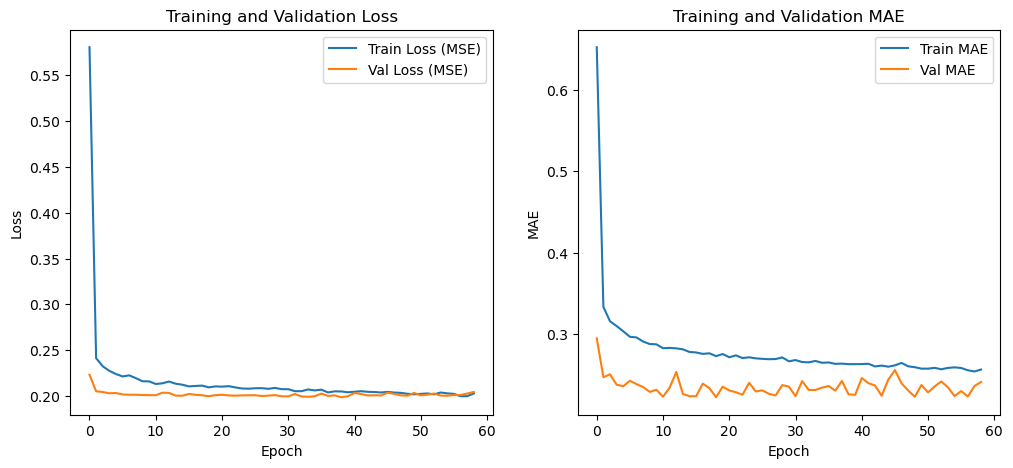

In [248]:
import matplotlib.pyplot as plt

# Plot MSE loss and MAE metric
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE metric
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [249]:
for t, p in zip(y_true, y_pred):
    print('📈', t)
    print('📉', p)

📈 [  1.       204.470001 206.899994 209.199997 204.050003]
📉 [  0.57593054 201.00803    200.4489     206.02048    198.41408   ]
📈 [  1.       221.529999 219.740005 223.800003 217.199997]
📉 [  0.46690717 219.62442    219.07182    223.04108    215.52943   ]
📈 [  0.       230.389999 226.050003 232.889999 225.169998]
📉 [  0.44366533 232.31778    232.09589    236.57907    229.01868   ]
📈 [  0.       202.699997 197.330002 203.339996 195.830002]
📉 [  0.518402 206.21358  206.71886  210.28201  202.89116 ]
📈 [  1.       279.029999 280.980011 287.390015 278.609985]
📉 [2.8588915e-01 2.8197220e+02 2.8300778e+02 2.8659973e+02 2.7323254e+02]
📈 [ 1.       20.16     20.65     20.690001 20.040001]
📉 [ 0.48860997 23.21836    24.169018   23.066803   23.697792  ]
📈 [  0.       202.       195.649994 204.589996 194.529999]
📉 [  0.4864315 205.09468   203.83812   207.72195   201.31926  ]
📈 [  0.       191.       189.399994 191.889999 187.5     ]
📉 [  0.41739547 192.74539    191.54962    193.6547     187.02232 

CNN Method

In [250]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dropout, Dense

def build_cnn_model(input_dim, output_dim, dropout_rate, learning_rate):
    model = Sequential()

    # Input shape must be (timesteps, features)
    model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same', input_shape=(input_dim, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dropout(dropout_rate))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(output_dim))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=custom_loss, metrics=['mae'])

    return model

In [251]:
model = build_cnn_model(input_dim, output_dim, dropout_rate, learning_rate)
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/200
43/43 - 1s - loss: 4.4936 - mae: 0.8693 - val_loss: 3.0149 - val_mae: 0.7567 - 1s/epoch - 29ms/step
Epoch 2/200
43/43 - 0s - loss: 1.8890 - mae: 0.5415 - val_loss: 0.9919 - val_mae: 0.3598 - 269ms/epoch - 6ms/step
Epoch 3/200
43/43 - 0s - loss: 1.1646 - mae: 0.3294 - val_loss: 1.0466 - val_mae: 0.3251 - 317ms/epoch - 7ms/step
Epoch 4/200
43/43 - 0s - loss: 1.1738 - mae: 0.3381 - val_loss: 1.1709 - val_mae: 0.3649 - 280ms/epoch - 7ms/step
Epoch 5/200
43/43 - 0s - loss: 0.9902 - mae: 0.3287 - val_loss: 0.9831 - val_mae: 0.3546 - 253ms/epoch - 6ms/step
Epoch 6/200
43/43 - 0s - loss: 1.2096 - mae: 0.3372 - val_loss: 1.1013 - val_mae: 0.2903 - 259ms/epoch - 6ms/step
Epoch 7/200
43/43 - 0s - loss: 1.2965 - mae: 0.3255 - val_loss: 1.0228 - val_mae: 0.2687 - 252ms/epoch - 6ms/step
Epoch 8/200
43/43 - 0s - loss: 1.1692 - mae: 0.3236 - val_loss: 1.0103 - val_mae: 0.3619 - 248ms/epoch - 6ms/step
Epoch 9/200
43/43 - 0s - loss: 1.1464 - mae: 0.3752 - val_loss: 0.9081 - val_mae: 0.3025 -

In [252]:
y_pred_scaled = model.predict(x_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

11/11 [==============================] - 0s 3ms/step


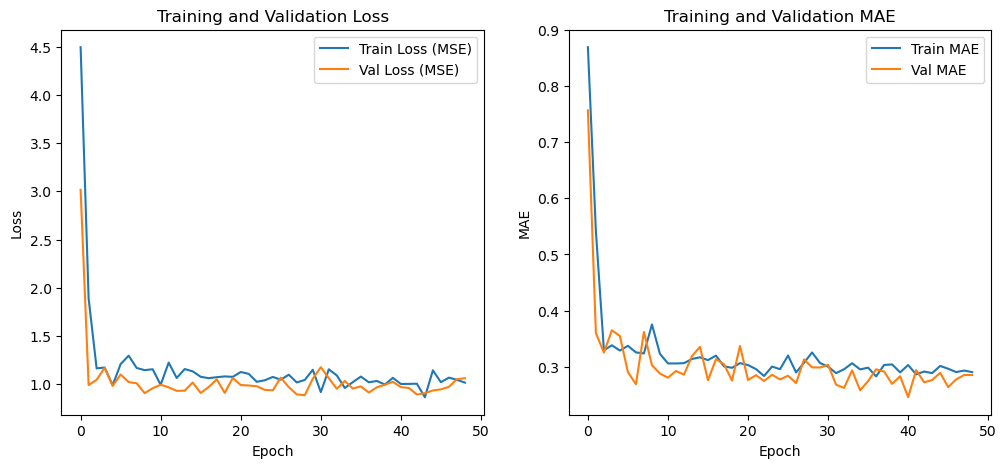

In [253]:
import matplotlib.pyplot as plt

# Plot MSE loss and MAE metric
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE metric
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [254]:
for t, p in zip(y_true, y_pred):
    print('📈', t)
    print('📉', p)

📈 [  1.       204.470001 206.899994 209.199997 204.050003]
📉 [  0.592602 221.51472  222.72801  223.66707  218.13104 ]
📈 [  1.       221.529999 219.740005 223.800003 217.199997]
📉 [  0.52735645 232.2875     231.6859     236.94095    227.65427   ]
📈 [  0.       230.389999 226.050003 232.889999 225.169998]
📉 [  0.5318707 246.09593   242.10251   248.36598   235.63199  ]
📈 [  0.       202.699997 197.330002 203.339996 195.830002]
📉 [  0.56061316 218.63664    217.5507     221.76848    213.33427   ]
📈 [  1.       279.029999 280.980011 287.390015 278.609985]
📉 [  0.49062482 291.6567     284.16837    292.30502    275.69937   ]
📈 [ 1.       20.16     20.65     20.690001 20.040001]
📉 [ 0.66388005 32.591248   29.20132    21.675522   27.662285  ]
📈 [  0.       202.       195.649994 204.589996 194.529999]
📉 [  0.5256562 214.40315   212.73831   217.84804   211.54897  ]
📈 [  0.       191.       189.399994 191.889999 187.5     ]
📉 [  0.57763845 206.52563    208.0392     209.35587    202.08754   ]
📈 [  1

LSTM 

In [265]:
from keras.layers import LSTM

def build_lstm_model(input_dim, output_dim):
    model = Sequential()
    model.add(LSTM(43, activation='relu', input_shape=(input_dim,1)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(output_dim))

    model.compile(optimizer='adam', loss=custom_loss, metrics=['mae'])
    
    return model

In [266]:
model = build_lstm_model(input_dim, output_dim)
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/200
43/43 - 2s - loss: 5.1935 - mae: 0.9148 - val_loss: 4.1270 - val_mae: 0.8770 - 2s/epoch - 53ms/step
Epoch 2/200
43/43 - 1s - loss: 4.5319 - mae: 0.6591 - val_loss: 1.5674 - val_mae: 0.5441 - 1s/epoch - 24ms/step
Epoch 3/200
43/43 - 1s - loss: 1.9269 - mae: 0.5449 - val_loss: 1.5082 - val_mae: 0.5310 - 977ms/epoch - 23ms/step
Epoch 4/200
43/43 - 1s - loss: 1.4293 - mae: 0.4570 - val_loss: 1.1544 - val_mae: 0.4393 - 988ms/epoch - 23ms/step
Epoch 5/200
43/43 - 1s - loss: 1.3755 - mae: 0.4010 - val_loss: 1.0931 - val_mae: 0.4009 - 981ms/epoch - 23ms/step
Epoch 6/200
43/43 - 1s - loss: 1.1818 - mae: 0.3624 - val_loss: 1.0221 - val_mae: 0.3535 - 978ms/epoch - 23ms/step
Epoch 7/200
43/43 - 1s - loss: 1.2248 - mae: 0.3287 - val_loss: 0.9864 - val_mae: 0.3284 - 989ms/epoch - 23ms/step
Epoch 8/200
43/43 - 1s - loss: 1.0857 - mae: 0.3180 - val_loss: 1.1214 - val_mae: 0.3251 - 994ms/epoch - 23ms/step
Epoch 9/200
43/43 - 1s - loss: 1.1920 - mae: 0.3266 - val_loss: 1.0541 - val_mae: 0.31

In [267]:
y_pred_scaled = model.predict(x_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

11/11 [==============================] - 0s 3ms/step


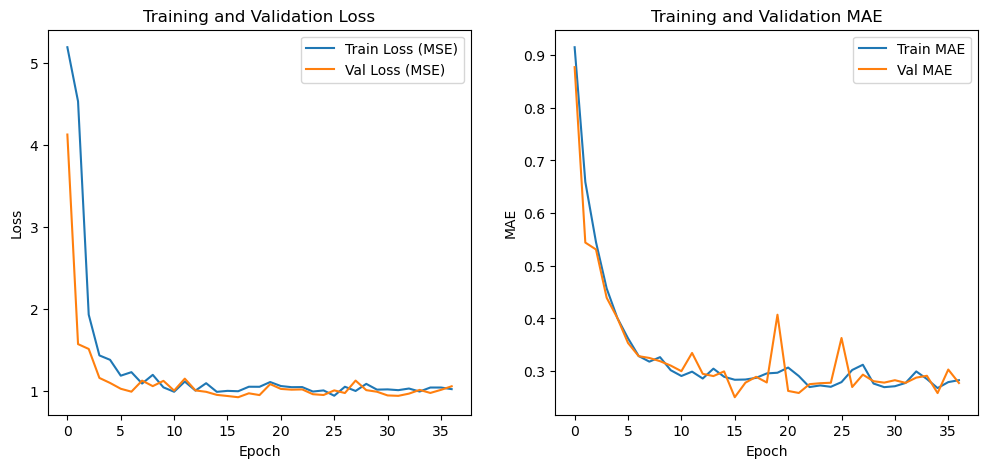

In [268]:
import matplotlib.pyplot as plt

# Plot MSE loss and MAE metric
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE metric
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [269]:
for t, p in zip(y_true, y_pred):
    print('📈', t)
    print('📉', p)

📈 [  1.       204.470001 206.899994 209.199997 204.050003]
📉 [  0.61522996 213.43884    215.98825    222.95193    207.96362   ]
📈 [  1.       221.529999 219.740005 223.800003 217.199997]
📉 [  0.58611614 231.11087    231.89929    238.12831    228.28088   ]
📈 [  0.       230.389999 226.050003 232.889999 225.169998]
📉 [  0.541774 230.42734  228.35129  233.02422  229.50446 ]
📈 [  0.       202.699997 197.330002 203.339996 195.830002]
📉 [  0.6055032 208.87103   212.28743   215.85239   203.70087  ]
📈 [  1.       279.029999 280.980011 287.390015 278.609985]
📉 [  0.5457033 276.79163   274.2754    280.25906   284.3494   ]
📈 [ 1.       20.16     20.65     20.690001 20.040001]
📉 [ 0.715882 27.471191 27.981129 29.243774 31.838394]
📈 [  0.       202.       195.649994 204.589996 194.529999]
📉 [  0.60910964 211.95998    215.32175    218.67995    206.21521   ]
📈 [  0.       191.       189.399994 191.889999 187.5     ]
📉 [  0.6530797 193.52629   202.28806   200.82935   187.97392  ]
📈 [  1.       205.990